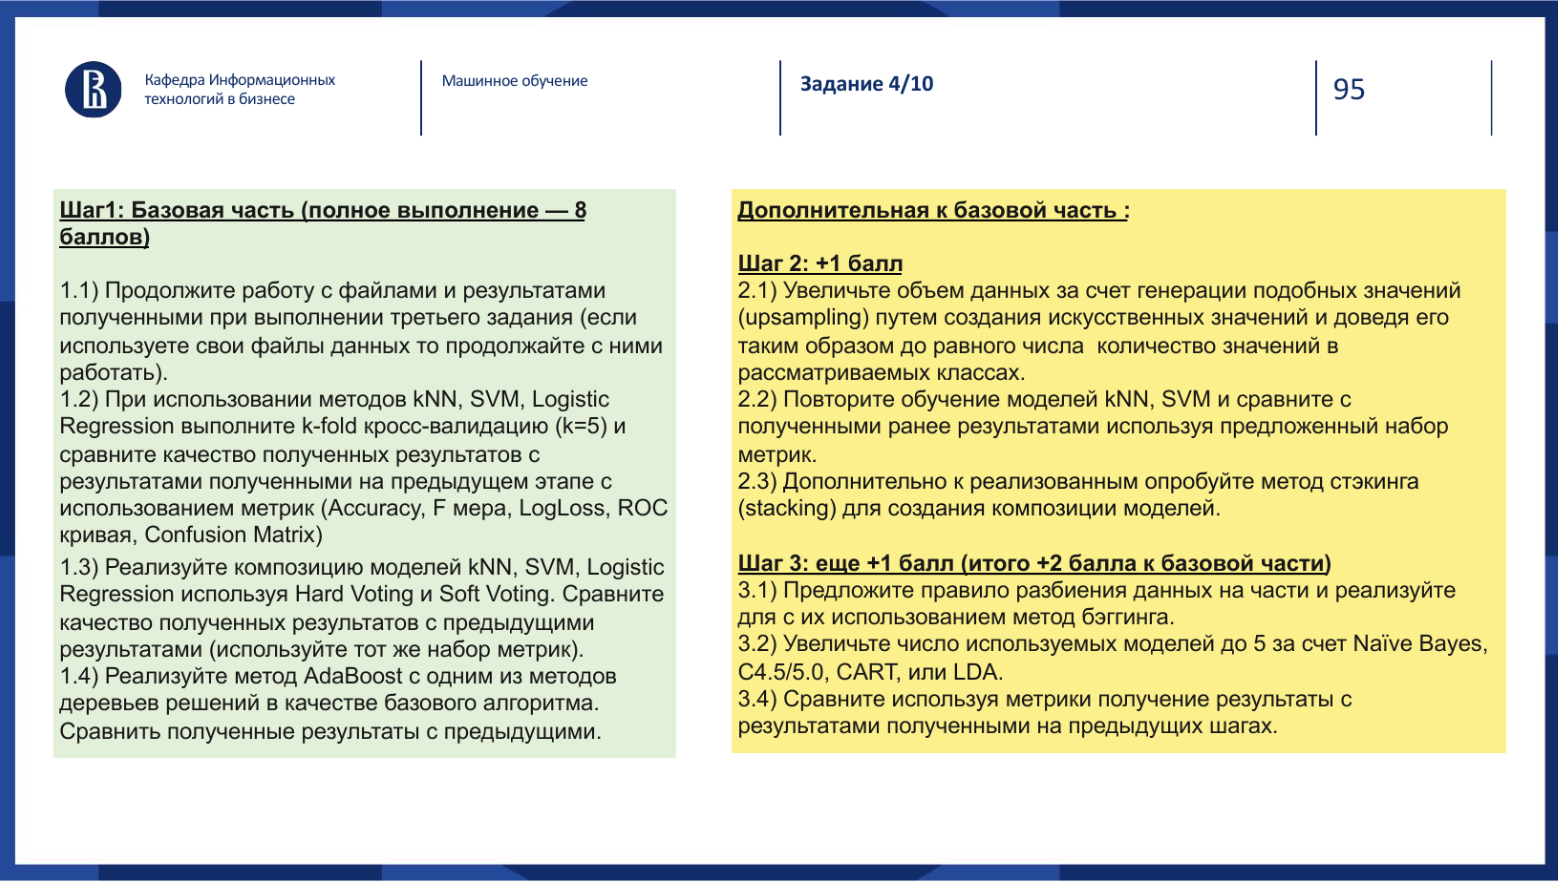

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.datasets import make_classification
from sklearn.model_selection import (
    train_test_split, KFold, cross_val_score, StratifiedKFold
)
from sklearn.utils import shuffle
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import (
    VotingClassifier, AdaBoostClassifier, BaggingClassifier,
    StackingClassifier, RandomForestClassifier
)
from sklearn.metrics import (
    accuracy_score, f1_score, log_loss, roc_curve, auc,
    confusion_matrix, classification_report, roc_auc_score
)
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [28]:
FILEPATH = 'building_materials_transactions.csv'
DATETIME_COL = 'date'
VALUE_COL = 'revenue'
N_LAGS = 5
TEST_SIZE = 0.2

df = pd.read_csv(FILEPATH)
df[DATETIME_COL] = pd.to_datetime(df[DATETIME_COL], errors='coerce')
df = df.dropna(subset=[DATETIME_COL, VALUE_COL]).sort_values(DATETIME_COL)

agg = {VALUE_COL: 'sum'}
if 'units' in df.columns:
    agg['units'] = 'sum'
for col in ['unit_price', 'housing_starts_index', 'lumber_price_index', 'mortgage_rate']:
    if col in df.columns:
        agg[col] = 'mean'

df_ts = df.groupby(DATETIME_COL).agg(agg).reset_index().sort_values(DATETIME_COL)

y_full = df_ts[VALUE_COL].values
dates = df_ts[DATETIME_COL].values
units_full = df_ts['units'].values if 'units' in df_ts.columns else None



year  month  week_of_year  housing_starts_index  lumber_price_index 
mortgage_rate  region_East_South_Central  region_Middle_Atlantic

In [43]:

drop_cols = ["revenue", "units", "unit_price", "date", "sku"]
X_df = df.drop(columns=drop_cols).copy()
cat_cols = ["region", "product_category", "channel", "customer_type"]
X_df = pd.get_dummies(X_df, columns=cat_cols, drop_first=True)
X_df = X_df.fillna(X_df.median(numeric_only=True))
X = X_df.values.astype(float)

y =  (df["revenue"] > 1000).astype(int).values

X, y = shuffle(X, y, random_state=RANDOM_STATE)
half = len(X) // 40
X, y = X[:half], y[:half]

print("=" * 70)
print("ДАННЫЕ")
print("=" * 70)
print(f"Размер: {X.shape}")
print(f"Распределение классов: {np.bincount(y)}")
print(f"Доля положительного класса: {y.mean():.3f}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)


ДАННЫЕ
Размер: (8500, 27)
Распределение классов: [4228 4272]
Доля положительного класса: 0.503


In [30]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te,
                   cv=None, plot_roc=False):
    """Обучает модель, считает метрики, при желании строит ROC."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_proba = (model.predict_proba(X_te)[:, 1]
               if hasattr(model, "predict_proba") else None)

    acc = accuracy_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)
    cm = confusion_matrix(y_te, y_pred)

    if y_proba is not None:
        ll = log_loss(y_te, y_proba)
        roc_auc = roc_auc_score(y_te, y_proba)
        fpr, tpr, _ = roc_curve(y_te, y_proba)
    else:
        ll, roc_auc, fpr, tpr = np.nan, np.nan, None, None

    cv_score = None
    if cv is not None:
        cv_scores = cross_val_score(model, X_tr, y_tr,
                                    cv=cv, scoring="f1")
        cv_score = cv_scores.mean()

    result = {
        "Модель": name,
        "Accuracy": acc,
        "F1": f1,
        "LogLoss": ll,
        "ROC_AUC": roc_auc,
        "CV_F1_mean": cv_score,
        "Confusion": cm
    }

    print(f"\n--- {name} ---")
    print(f"Accuracy : {acc:.4f}")
    print(f"F1       : {f1:.4f}")
    print(f"LogLoss  : {ll:.4f}" if not np.isnan(ll) else "LogLoss  : n/a")
    print(f"ROC AUC  : {roc_auc:.4f}")
    if cv_score is not None:
        print(f"CV F1 (mean): {cv_score:.4f}")
    print("Confusion matrix:")
    print(cm)

    if plot_roc and fpr is not None:
        plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

    return result
def compare_table(results):
    """Печатает сводную таблицу результатов."""
    df = pd.DataFrame(results)
    df = df.drop(columns=["Confusion"])
    print("\n" + "=" * 70)
    print("СВОДНАЯ ТАБЛИЦА")
    print("=" * 70)
    print(df.to_string(index=False, float_format="%.4f"))
    return df




KNN SVM LOGISTIC REGRESSION


######################################################################
#K-Fold CV (k=5) для kNN, SVM, Logistic Regression
######################################################################

--- kNN ---
Accuracy : 0.7351
F1       : 0.7521
LogLoss  : 2.1046
ROC AUC  : 0.7869
CV F1 (mean): 0.7479
Confusion matrix:
[[708 349]
 [214 854]]

--- SVM ---
Accuracy : 0.7567
F1       : 0.7723
LogLoss  : 0.5200
ROC AUC  : 0.8241
CV F1 (mean): 0.7926
Confusion matrix:
[[731 326]
 [191 877]]

--- LogReg ---
Accuracy : 0.7525
F1       : 0.7656
LogLoss  : 0.5074
ROC AUC  : 0.8265
CV F1 (mean): 0.7819
Confusion matrix:
[[740 317]
 [209 859]]


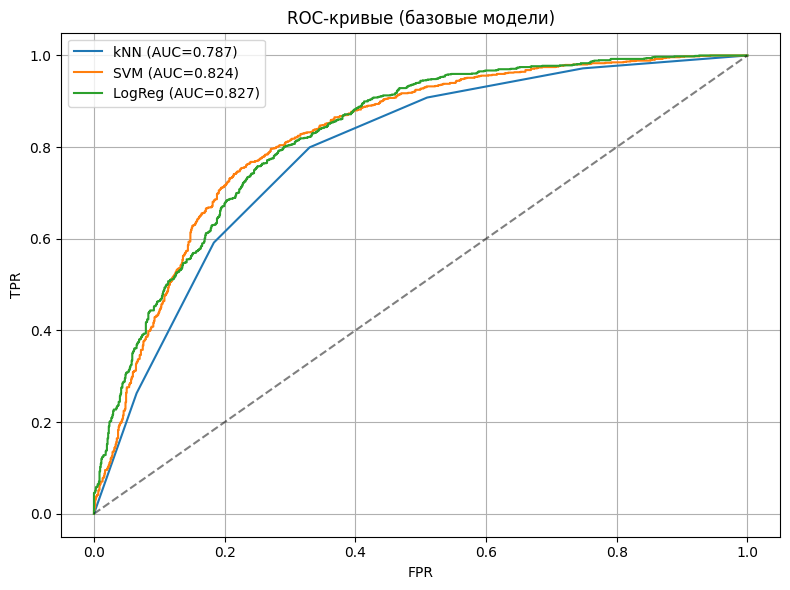


СВОДНАЯ ТАБЛИЦА
Модель  Accuracy     F1  LogLoss  ROC_AUC  CV_F1_mean
   kNN    0.7351 0.7521   2.1046   0.7869      0.7479
   SVM    0.7567 0.7723   0.5200   0.8241      0.7926
LogReg    0.7525 0.7656   0.5074   0.8265      0.7819


,Модель,Accuracy,F1,LogLoss,ROC_AUC,CV_F1_mean
0,kNN,0.735059,0.752092,2.104599,0.786896,0.747944
1,SVM,0.756706,0.772347,0.519986,0.824098,0.792643
2,LogReg,0.752471,0.765597,0.507358,0.826520,0.781938


In [31]:
print("\n" + "#" * 70)
print("#K-Fold CV (k=5) для kNN, SVM, Logistic Regression")
print("#" * 70)

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Пайплайны: масштабирование + модель (важно для kNN и SVM)
models_cv = {
    "kNN": Pipeline([("scaler", StandardScaler()),
                     ("clf", KNeighborsClassifier(n_neighbors=5))]),
    "SVM": Pipeline([("scaler", StandardScaler()),
                     ("clf", SVC(probability=True,
                                 random_state=RANDOM_STATE))]),
    "LogReg": Pipeline([("scaler", StandardScaler()),
                        ("clf", LogisticRegression(max_iter=1000,
                                                   random_state=RANDOM_STATE))]),
}

results_step1 = []
plt.figure(figsize=(8, 6))

for name, model in models_cv.items():
    res = evaluate_model(name, model, X_train, y_train,
                         X_test, y_test, cv=kf, plot_roc=True)
    results_step1.append(res)

plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("ROC-кривые (базовые модели)")
plt.legend(); plt.grid(True); plt.tight_layout()
plt.show()

compare_table(results_step1)

HARD AND SOFT VOTINGS


######################################################################
#Композиция моделей: Hard Voting и Soft Voting
######################################################################

--- Hard Voting ---
Accuracy : 0.7558
F1       : 0.7715
LogLoss  : n/a
ROC AUC  : nan
CV F1 (mean): 0.7919
Confusion matrix:
[[730 327]
 [192 876]]

--- Soft Voting ---
Accuracy : 0.7558
F1       : 0.7713
LogLoss  : 0.5102
ROC AUC  : 0.8279
CV F1 (mean): 0.7858
Confusion matrix:
[[731 326]
 [193 875]]


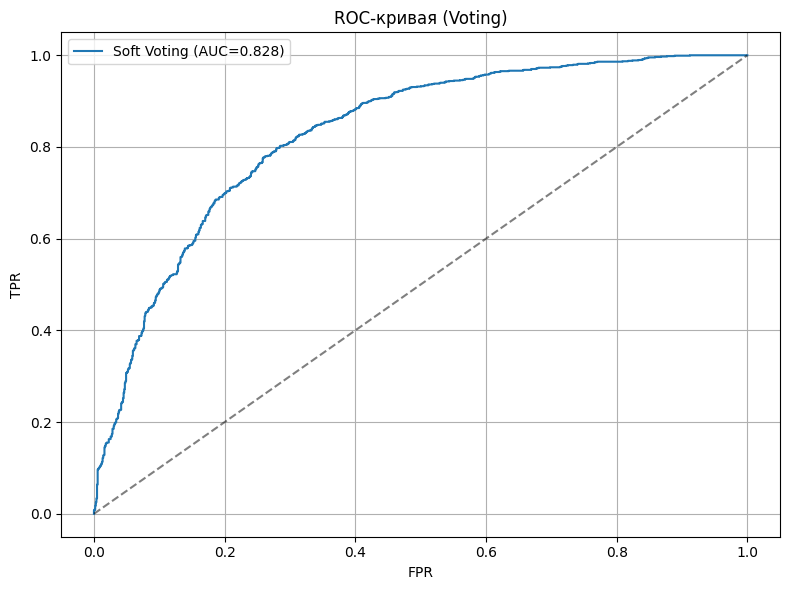

In [41]:
print("\n" + "#" * 70)
print("#Композиция моделей: Hard Voting и Soft Voting")
print("#" * 70)

# Базовые классификаторы (после масштабирования)
base_estimators = [
    ("knn", Pipeline([("scaler", StandardScaler()),
                      ("clf", KNeighborsClassifier(n_neighbors=5))])),
    ("svm", Pipeline([("scaler", StandardScaler()),
                      ("clf", SVC(probability=True,
                                  random_state=RANDOM_STATE))])),
    ("lr",  Pipeline([("scaler", StandardScaler()),
                      ("clf", LogisticRegression(max_iter=1000,
                                                 random_state=RANDOM_STATE))])),
]

voting_hard = VotingClassifier(estimators=base_estimators, voting="hard")
voting_soft = VotingClassifier(estimators=base_estimators, voting="soft")

results_voting = []
plt.figure(figsize=(8, 6))
for name, model in [("Hard Voting", voting_hard),
                    ("Soft Voting", voting_soft)]:
    res = evaluate_model(name, model, X_train, y_train,
                         X_test, y_test, cv=kf, plot_roc=True)
    results_voting.append(res)

plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("ROC-кривая (Voting)")
plt.legend(); plt.grid(True); plt.tight_layout()
plt.show()




In [33]:
compare_table(results_step1 + results_voting)


СВОДНАЯ ТАБЛИЦА
     Модель  Accuracy     F1  LogLoss  ROC_AUC  CV_F1_mean
        kNN    0.7351 0.7521   2.1046   0.7869      0.7479
        SVM    0.7567 0.7723   0.5200   0.8241      0.7926
     LogReg    0.7525 0.7656   0.5074   0.8265      0.7819
Hard Voting    0.7558 0.7715      NaN      NaN      0.7919
Soft Voting    0.7558 0.7713   0.5102   0.8279      0.7858


,Модель,Accuracy,F1,LogLoss,ROC_AUC,CV_F1_mean
0,kNN,0.735059,0.752092,2.104599,0.786896,0.747944
1,SVM,0.756706,0.772347,0.519986,0.824098,0.792643
2,LogReg,0.752471,0.765597,0.507358,0.826520,0.781938
3,Hard Voting,0.755765,0.771466,NaN,NaN,0.791867
4,Soft Voting,0.755765,0.771265,0.510185,0.827893,0.785782



######################################################################
# AdaBoost (базовый алгоритм — Decision Tree)
######################################################################

--- AdaBoost (DT) ---
Accuracy : 0.7656
F1       : 0.7713
LogLoss  : 0.5566
ROC AUC  : 0.8417
CV F1 (mean): 0.7889
Confusion matrix:
[[787 270]
 [228 840]]


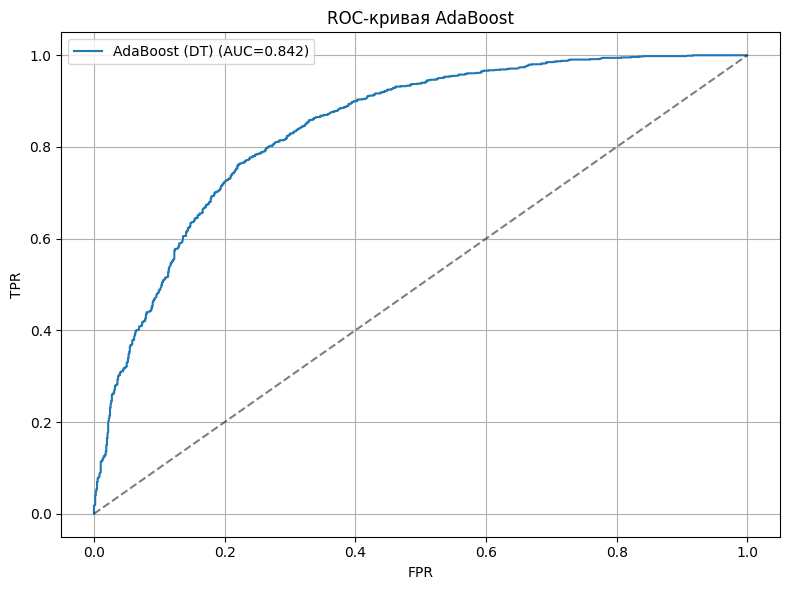


СВОДНАЯ ТАБЛИЦА
       Модель  Accuracy     F1  LogLoss  ROC_AUC  CV_F1_mean
          kNN    0.7351 0.7521   2.1046   0.7869      0.7479
          SVM    0.7567 0.7723   0.5200   0.8241      0.7926
       LogReg    0.7525 0.7656   0.5074   0.8265      0.7819
  Hard Voting    0.7558 0.7715      NaN      NaN      0.7919
  Soft Voting    0.7558 0.7713   0.5102   0.8279      0.7858
AdaBoost (DT)    0.7656 0.7713   0.5566   0.8417      0.7889


,Модель,Accuracy,F1,LogLoss,ROC_AUC,CV_F1_mean
0,kNN,0.735059,0.752092,2.104599,0.786896,0.747944
1,SVM,0.756706,0.772347,0.519986,0.824098,0.792643
2,LogReg,0.752471,0.765597,0.507358,0.826520,0.781938
3,Hard Voting,0.755765,0.771466,NaN,NaN,0.791867
4,Soft Voting,0.755765,0.771265,0.510185,0.827893,0.785782
5,AdaBoost (DT),0.765647,0.771350,0.556554,0.841683,0.788854


In [34]:
print("\n" + "#" * 70)
print("# AdaBoost (базовый алгоритм — Decision Tree)")
print("#" * 70)

ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE),
    n_estimators=100,
    learning_rate=0.5,
    random_state=RANDOM_STATE
)

results_ada = []
plt.figure(figsize=(8, 6))
res = evaluate_model("AdaBoost (DT)", ada, X_train, y_train,
                     X_test, y_test, cv=kf, plot_roc=True)
results_ada.append(res)

plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("ROC-кривая AdaBoost")
plt.legend(); plt.grid(True); plt.tight_layout()
plt.show()

compare_table(results_step1 + results_voting + results_ada)

+1 БАЛЛ

In [ ]:
print("\n" + "#" * 70)
print("# Upsampling (балансировка классов)")
print("# "* 70)

ros = RandomOverSampler(random_state=RANDOM_STATE)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)

smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("До балансировки :", np.bincount(y_train))
print("После RandomOver:", np.bincount(y_train_ros))
print("После SMOTE     :", np.bincount(y_train_smote))


######################################################################
# Upsampling (балансировка классов)
# # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # 
До балансировки : [3171 3204]
После RandomOver: [3204 3204]
После SMOTE     : [3204 3204]



######################################################################
# kNN и SVM после балансировки (SMOTE)
######################################################################

--- kNN + SMOTE ---
Accuracy : 0.7355
F1       : 0.7524
LogLoss  : 2.1372
ROC AUC  : 0.7862
Confusion matrix:
[[709 348]
 [214 854]]

--- SVM + SMOTE ---
Accuracy : 0.7572
F1       : 0.7725
LogLoss  : 0.5194
ROC AUC  : 0.8244
Confusion matrix:
[[733 324]
 [192 876]]


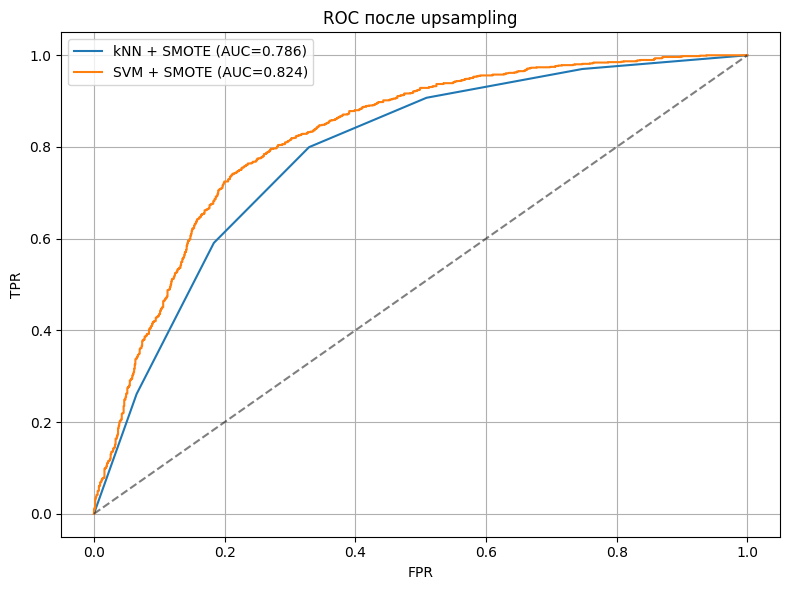

In [36]:
print("\n" + "#" * 70)
print("# kNN и SVM после балансировки (SMOTE)")
print("#" * 70)

results_upsample = []
plt.figure(figsize=(8, 6))

for name, model in [
    ("kNN + SMOTE", Pipeline([("scaler", StandardScaler()),
                              ("clf", KNeighborsClassifier(n_neighbors=5))])),
    ("SVM + SMOTE", Pipeline([("scaler", StandardScaler()),
                              ("clf", SVC(probability=True,
                                          random_state=RANDOM_STATE))])),
]:
    res = evaluate_model(name, model,
                         X_train_smote, y_train_smote,
                         X_test, y_test, plot_roc=True)
    results_upsample.append(res)

plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("ROC после upsampling")
plt.legend(); plt.grid(True); plt.tight_layout()
plt.show()


In [37]:
compare_table(results_step1 + results_upsample)


СВОДНАЯ ТАБЛИЦА
     Модель  Accuracy     F1  LogLoss  ROC_AUC  CV_F1_mean
        kNN    0.7351 0.7521   2.1046   0.7869      0.7479
        SVM    0.7567 0.7723   0.5200   0.8241      0.7926
     LogReg    0.7525 0.7656   0.5074   0.8265      0.7819
kNN + SMOTE    0.7355 0.7524   2.1372   0.7862         NaN
SVM + SMOTE    0.7572 0.7725   0.5194   0.8244         NaN


,Модель,Accuracy,F1,LogLoss,ROC_AUC,CV_F1_mean
0,kNN,0.735059,0.752092,2.104599,0.786896,0.747944
1,SVM,0.756706,0.772347,0.519986,0.824098,0.792643
2,LogReg,0.752471,0.765597,0.507358,0.826520,0.781938
3,kNN + SMOTE,0.735529,0.752423,2.137248,0.786220,NaN
4,SVM + SMOTE,0.757176,0.772487,0.519447,0.824419,NaN



######################################################################
# Stacking (мета-модель — LogisticRegression)
######################################################################

--- Stacking ---
Accuracy : 0.7553
F1       : 0.7689
LogLoss  : 0.5116
ROC AUC  : 0.8332
CV F1 (mean): 0.7893
Confusion matrix:
[[740 317]
 [203 865]]


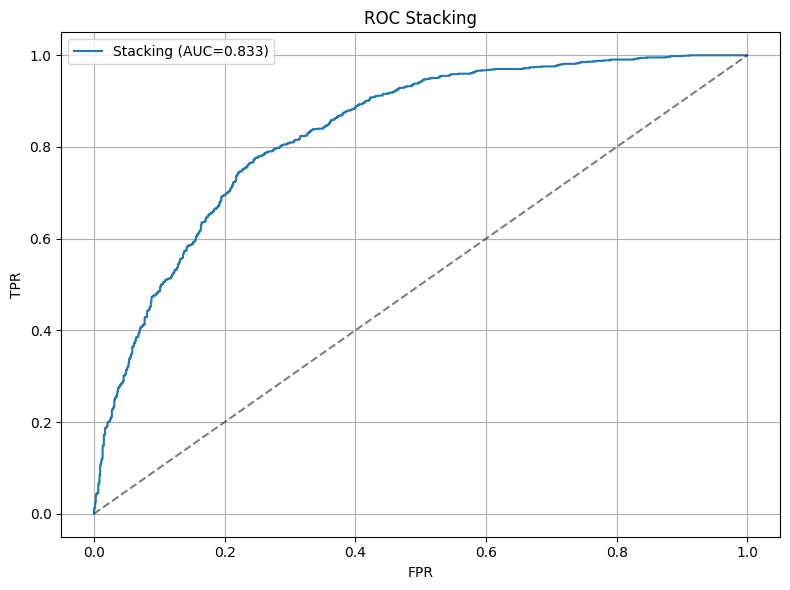


СВОДНАЯ ТАБЛИЦА
       Модель  Accuracy     F1  LogLoss  ROC_AUC  CV_F1_mean
          kNN    0.7351 0.7521   2.1046   0.7869      0.7479
          SVM    0.7567 0.7723   0.5200   0.8241      0.7926
       LogReg    0.7525 0.7656   0.5074   0.8265      0.7819
  Hard Voting    0.7558 0.7715      NaN      NaN      0.7919
  Soft Voting    0.7558 0.7713   0.5102   0.8279      0.7858
AdaBoost (DT)    0.7656 0.7713   0.5566   0.8417      0.7889
  kNN + SMOTE    0.7355 0.7524   2.1372   0.7862         NaN
  SVM + SMOTE    0.7572 0.7725   0.5194   0.8244         NaN
     Stacking    0.7553 0.7689   0.5116   0.8332      0.7893


,Модель,Accuracy,F1,LogLoss,ROC_AUC,CV_F1_mean
0,kNN,0.735059,0.752092,2.104599,0.786896,0.747944
1,SVM,0.756706,0.772347,0.519986,0.824098,0.792643
2,LogReg,0.752471,0.765597,0.507358,0.826520,0.781938
3,Hard Voting,0.755765,0.771466,NaN,NaN,0.791867
4,Soft Voting,0.755765,0.771265,0.510185,0.827893,0.785782
5,AdaBoost (DT),0.765647,0.771350,0.556554,0.841683,0.788854
6,kNN + SMOTE,0.735529,0.752423,2.137248,0.786220,NaN
7,SVM + SMOTE,0.757176,0.772487,0.519447,0.824419,NaN
8,Stacking,0.755294,0.768889,0.511597,0.833152,0.789317


In [38]:
print("\n" + "#" * 70)
print("# Stacking (мета-модель — LogisticRegression)")
print("#" * 70)

stacking = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(max_iter=1000,
                                       random_state=RANDOM_STATE),
    cv=5,
    passthrough=False
)

results_stack = []
plt.figure(figsize=(8, 6))
res = evaluate_model("Stacking", stacking, X_train, y_train,
                     X_test, y_test, cv=kf, plot_roc=True)
results_stack.append(res)

plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("ROC Stacking")
plt.legend(); plt.grid(True); plt.tight_layout()
plt.show()
compare_table(results_step1 + results_voting + results_ada
              + results_upsample + results_stack)


######################################################################
# ИТОГОВОЕ СРАВНЕНИЕ
######################################################################

СВОДНАЯ ТАБЛИЦА
       Модель  Accuracy     F1  LogLoss  ROC_AUC  CV_F1_mean
          kNN    0.7351 0.7521   2.1046   0.7869      0.7479
          SVM    0.7567 0.7723   0.5200   0.8241      0.7926
       LogReg    0.7525 0.7656   0.5074   0.8265      0.7819
  Hard Voting    0.7558 0.7715      NaN      NaN      0.7919
  Soft Voting    0.7558 0.7713   0.5102   0.8279      0.7858
AdaBoost (DT)    0.7656 0.7713   0.5566   0.8417      0.7889
  kNN + SMOTE    0.7355 0.7524   2.1372   0.7862         NaN
  SVM + SMOTE    0.7572 0.7725   0.5194   0.8244         NaN
     Stacking    0.7553 0.7689   0.5116   0.8332      0.7893

Результаты сохранены в final_results.csv


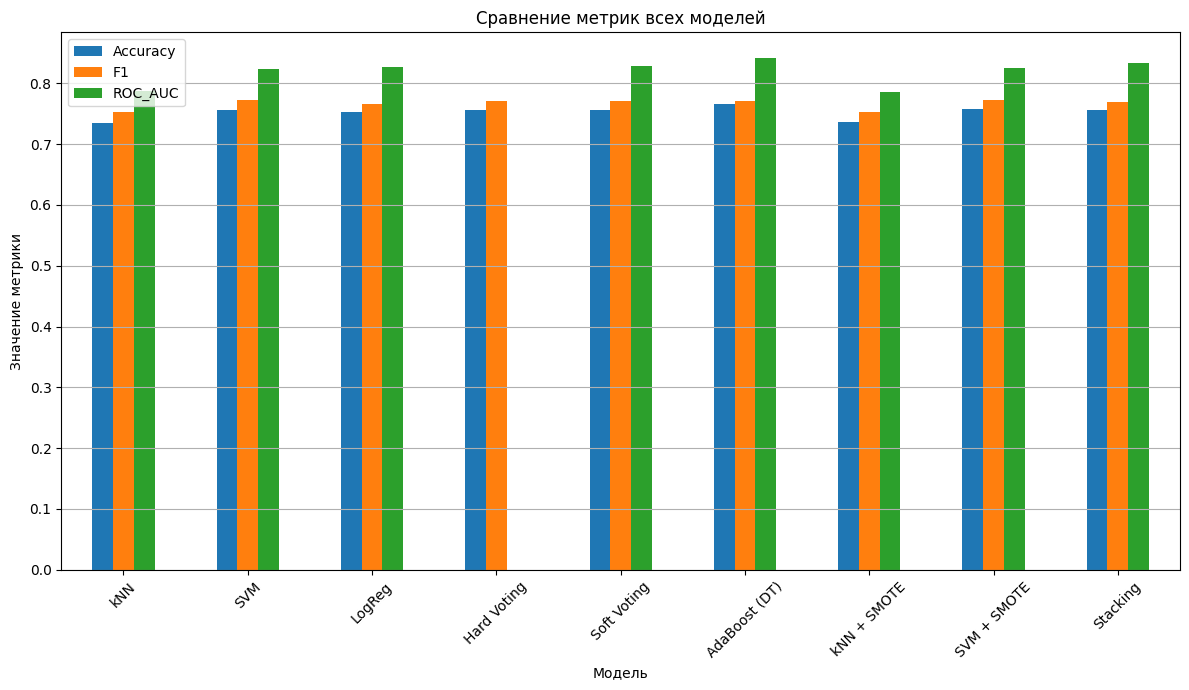

In [ ]:
print("\n" + "#" * 70)
print("# ИТОГОВОЕ СРАВНЕНИЕ")
print("#" * 70)

all_results = (results_step1 + results_voting + results_ada
               + results_upsample + results_stack)

final_df = compare_table(all_results)

fig, ax = plt.subplots(figsize=(12, 7))
final_df_plot = final_df.set_index("Модель")[["Accuracy", "F1", "ROC_AUC"]]
final_df_plot.plot(kind="bar", ax=ax, rot=45)
ax.set_title("Сравнение метрик всех моделей")
ax.set_ylabel("Значение метрики")
ax.grid(True, axis="y")
plt.tight_layout()
plt.show()